# Parte 1: Análisis Exploratorio de Datos (EDA)

El objetivo de este notebook es conectarse a **Snowflake**, extraer un subset manejable (o trabajar mediante *pushdown*) desde la tabla `analytics.obt_trips`, y entender la distribución de los datos y el negocio.

## Objetivos
1. Validar la conexión a Snowflake usando variables de entorno.
2. Entender el comportamiento del *Target* (`total_amount`).
3. Investigar la correlación entre variables independientes y descubrir posibles casos de *Data Leakage*.
4. Analizar la cardinalidad y distribución estadística (boxplots, histogramas).

### 1. Conexión a Snowflake y Extracción de Datos

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv
import snowflake.connector

load_dotenv('../.env')

conn = snowflake.connector.connect(
    user=os.getenv("SNOWFLAKE_USER"),
    password=os.getenv("SNOWFLAKE_PASSWORD"),
    account=os.getenv("SNOWFLAKE_ACCOUNT"),
    warehouse=os.getenv("SNOWFLAKE_WAREHOUSE"),
    database=os.getenv("SNOWFLAKE_DATABASE"),
    role=os.getenv("SNOWFLAKE_ROLE", "ACCOUNTADMIN")
)

# Descargar muestra del 1% para EDA
query = "SELECT * FROM ANALYTICS.REFINED.OBT_TRIPS SAMPLE (1);"
df = pd.read_sql(query, conn)
df.head()

C:\Users\Lhao\AppData\Local\Temp\ipykernel_37100\3225458519.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,VENDOR_ID,PICKUP_DATETIME,DROPOFF_DATETIME,PASSENGER_COUNT,TRIP_DISTANCE,RATE_CODE_ID,STORE_AND_FWD_FLAG,PU_LOCATION_ID,DO_LOCATION_ID,PAYMENT_TYPE,...,EHAIL_FEE,TRIP_TYPE,SOURCE_YEAR,SOURCE_MONTH,SERVICE_TYPE,RUN_ID,INGESTED_AT_UTC,TRIP_DURATION_MIN,AVG_SPEED_MPH,TIP_PCT
0,2,2015-06-08 10:33:12,2015-06-08 10:46:31,1.0,1.72,1.0,N,186,50,2.0,...,NaN,NaN,2015,6,yellow,run_local_python_ingestion,2026-05-02 19:09:52.416283,13.32,7.75,0.00
1,2,2015-06-08 10:07:31,2015-06-08 10:19:22,3.0,1.83,1.0,N,100,237,1.0,...,NaN,NaN,2015,6,yellow,run_local_python_ingestion,2026-05-02 19:09:52.416283,11.85,9.27,0.00
2,1,2015-06-08 10:38:40,2015-06-08 10:45:28,1.0,0.90,1.0,N,236,237,2.0,...,NaN,NaN,2015,6,yellow,run_local_python_ingestion,2026-05-02 19:09:52.416283,6.80,7.94,0.00
3,1,2015-06-08 10:43:27,2015-06-08 10:47:05,1.0,0.70,1.0,N,114,249,1.0,...,NaN,NaN,2015,6,yellow,run_local_python_ingestion,2026-05-02 19:09:52.416283,3.63,11.56,29.33
4,2,2015-06-08 10:39:21,2015-06-08 11:00:39,1.0,3.19,1.0,N,75,143,1.0,...,NaN,NaN,2015,6,yellow,run_local_python_ingestion,2026-05-02 19:09:52.416283,21.30,8.99,0.00


In [17]:
print(len(df))

8547311


In [18]:
print(df.dtypes)

VENDOR_ID                         int64
PICKUP_DATETIME          datetime64[ns]
DROPOFF_DATETIME         datetime64[ns]
PASSENGER_COUNT                 float64
TRIP_DISTANCE                   float64
RATE_CODE_ID                    float64
STORE_AND_FWD_FLAG               object
PU_LOCATION_ID                    int64
DO_LOCATION_ID                    int64
PAYMENT_TYPE                    float64
FARE_AMOUNT                     float64
EXTRA                           float64
MTA_TAX                         float64
TIP_AMOUNT                      float64
TOLLS_AMOUNT                    float64
IMPROVEMENT_SURCHARGE           float64
TOTAL_AMOUNT                    float64
CONGESTION_SURCHARGE            float64
AIRPORT_FEE                     float64
EHAIL_FEE                       float64
TRIP_TYPE                       float64
SOURCE_YEAR                       int64
SOURCE_MONTH                      int64
SERVICE_TYPE                     object
RUN_ID                           object


In [19]:
df.describe()

,VENDOR_ID,PICKUP_DATETIME,DROPOFF_DATETIME,PASSENGER_COUNT,TRIP_DISTANCE,RATE_CODE_ID,PU_LOCATION_ID,DO_LOCATION_ID,PAYMENT_TYPE,FARE_AMOUNT,...,CONGESTION_SURCHARGE,AIRPORT_FEE,EHAIL_FEE,TRIP_TYPE,SOURCE_YEAR,SOURCE_MONTH,INGESTED_AT_UTC,TRIP_DURATION_MIN,AVG_SPEED_MPH,TIP_PCT
count,8.547311e+06,8547311,8547311,8.354134e+06,8.547311e+06,8.354134e+06,8.547311e+06,8.547311e+06,8.528516e+06,8.547311e+06,...,2.851270e+06,1.699121e+06,22.0,649037.000000,8.547311e+06,8.547311e+06,8547311,8.547311e+06,8.547311e+06,8.544814e+06
mean,1.626480e+00,2018-10-04 12:40:30.653315328,2018-10-04 12:57:39.870110464,1.552205e+00,3.091993e+00,1.227093e+00,1.590931e+02,1.587107e+02,1.290400e+00,1.405172e+01,...,2.231362e+00,1.275590e-01,0.0,1.019940,2.018269e+03,6.381424e+00,2026-05-02 20:40:33.739300352,1.715361e+01,1.162847e+01,1.619675e+01
min,1.000000e+00,2015-01-01 00:02:15,2015-01-01 00:07:44,0.000000e+00,1.000000e-02,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.0,1.000000,2.015000e+03,1.000000e+00,2026-05-02 18:54:45.457589,2.000000e-02,0.000000e+00,0.000000e+00
25%,1.000000e+00,2016-04-25 15:22:31,2016-04-25 15:35:56.500000,1.000000e+00,1.010000e+00,1.000000e+00,1.070000e+02,1.070000e+02,1.000000e+00,7.000000e+00,...,2.500000e+00,0.000000e+00,0.0,1.000000,2.016000e+03,3.000000e+00,2026-05-02 19:42:56.759205888,6.900000e+00,7.550000e+00,0.000000e+00
50%,2.000000e+00,2017-12-10 03:43:28,2017-12-10 04:02:17,1.000000e+00,1.730000e+00,1.000000e+00,1.610000e+02,1.610000e+02,1.000000e+00,1.000000e+01,...,2.500000e+00,0.000000e+00,0.0,1.000000,2.017000e+03,6.000000e+00,2026-05-02 20:36:52.008457984,1.148000e+01,1.020000e+01,2.000000e+01
75%,2.000000e+00,2020-01-29 14:34:39.500000,2020-01-29 14:52:59,2.000000e+00,3.260000e+00,1.000000e+00,2.310000e+02,2.330000e+02,2.000000e+00,1.600000e+01,...,2.500000e+00,0.000000e+00,0.0,1.000000,2.020000e+03,9.000000e+00,2026-05-02 21:35:11.890724096,1.875000e+01,1.390000e+01,2.480000e+01
max,6.000000e+00,2025-12-31 23:58:22,2026-01-01 10:42:50,9.000000e+00,2.416400e+02,9.900000e+01,2.650000e+02,2.650000e+02,5.000000e+00,4.007500e+03,...,2.750000e+00,1.750000e+00,0.0,2.000000,2.025000e+03,1.200000e+01,2026-05-02 23:19:30.566872,1.107255e+05,1.500200e+02,1.101000e+06
std,4.931550e-01,NaN,NaN,1.193753e+00,3.867902e+00,4.234471e+00,6.834353e+01,7.141359e+01,5.177088e-01,1.266081e+01,...,7.770833e-01,4.335425e-01,0.0,0.139795,3.025338e+00,3.477502e+00,NaN,7.530564e+01,6.379814e+00,7.790184e+02


### 2. Análisis Univariado del Target (`total_amount`)

count    8.547311e+06
mean     1.864725e+01
std      1.595774e+01
min      0.000000e+00
25%      9.800000e+00
50%      1.380000e+01
75%      2.080000e+01
max      4.009300e+03
Name: TOTAL_AMOUNT, dtype: float64


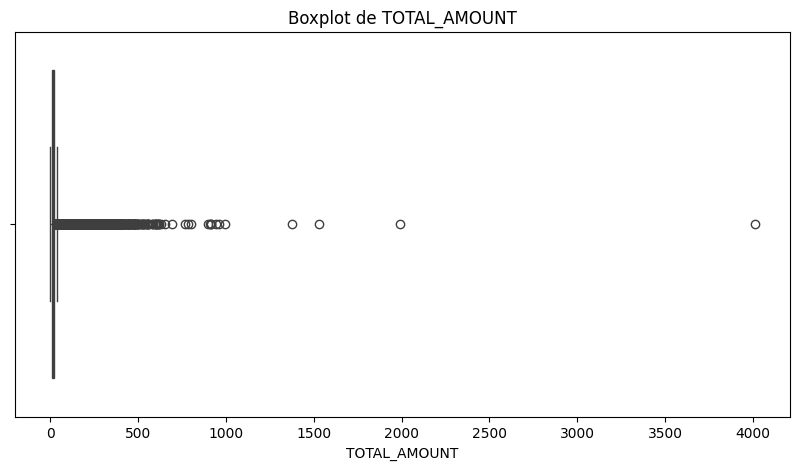

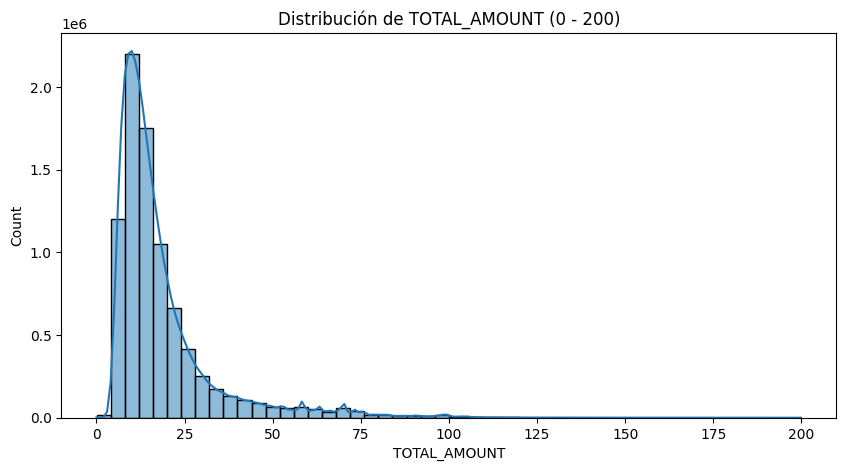

In [20]:
# Resumen estadístico del target
print(df['TOTAL_AMOUNT'].describe())

# Boxplot para identificar outliers extremos
plt.figure(figsize=(10,5))
sns.boxplot(x=df['TOTAL_AMOUNT'])
plt.title('Boxplot de TOTAL_AMOUNT')
plt.show()

# Histograma limitando el rango para ver la distribución principal
plt.figure(figsize=(10,5))
sns.histplot(df[(df['TOTAL_AMOUNT'] > 0) & (df['TOTAL_AMOUNT'] < 200)]['TOTAL_AMOUNT'], bins=50, kde=True)
plt.title('Distribución de TOTAL_AMOUNT (0 - 200)')
plt.show()

### 3. Análisis Bivariado (Features vs Target)

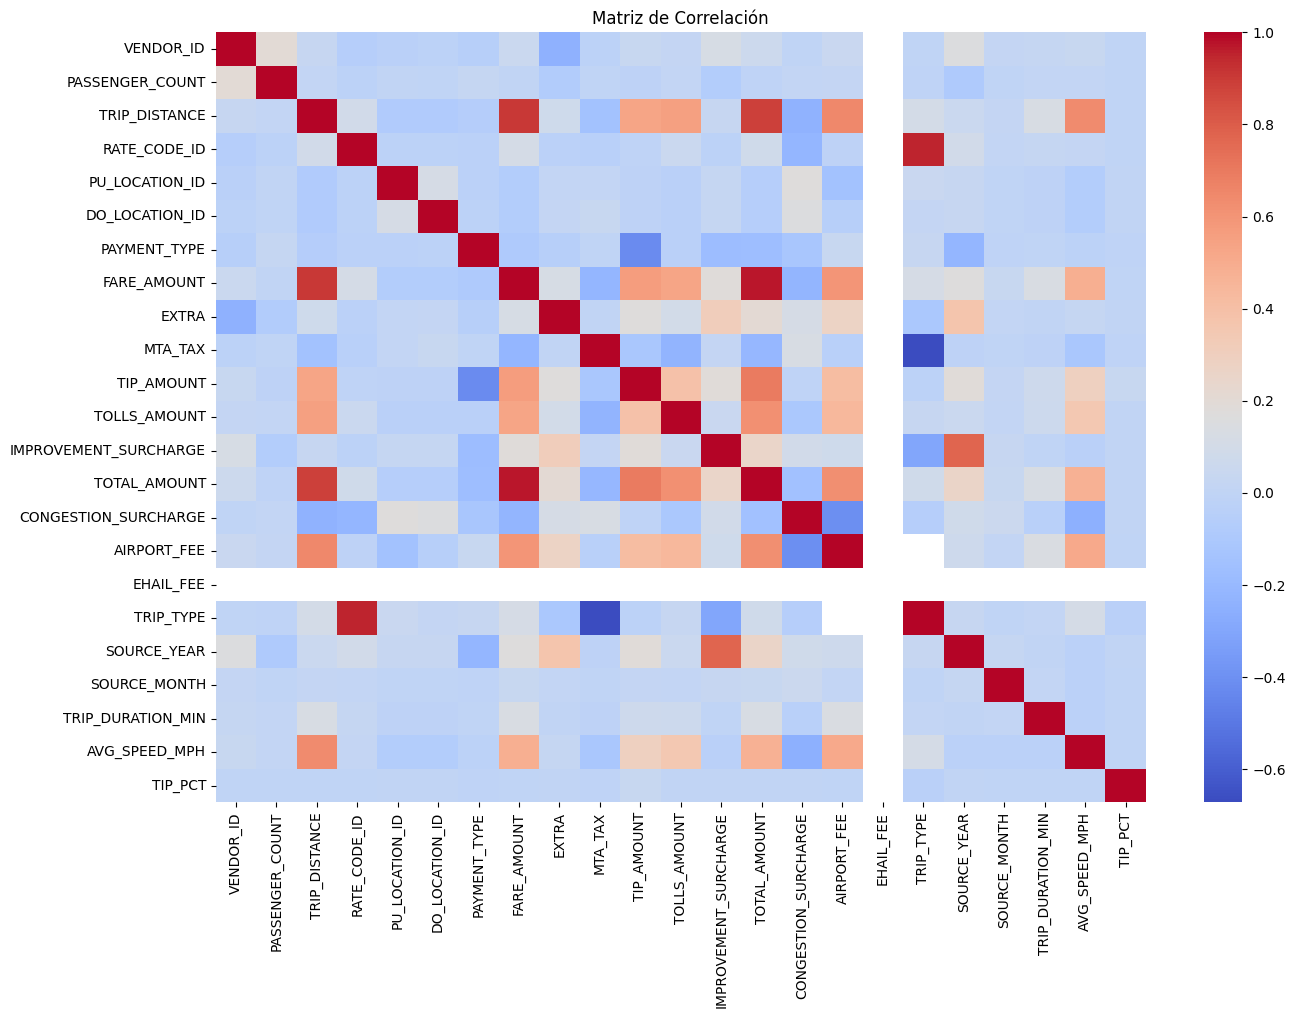

Variables sospechosas de leakage:
['FARE_AMOUNT', 'TIP_AMOUNT', 'TOLLS_AMOUNT', 'EXTRA', 'MTA_TAX', 'IMPROVEMENT_SURCHARGE', 'CONGESTION_SURCHARGE']


In [21]:
# Identificamos variables numéricas para correlación
num_cols = df.select_dtypes(include=[np.number]).columns

# Heatmap de correlaciones
plt.figure(figsize=(15,10))
sns.heatmap(df[num_cols].corr(), annot=False, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

# Leakage evidente: fare_amount, tip_amount, tolls_amount, extra, mta_tax
# están directamente sumados en total_amount.
print("Variables sospechosas de leakage:")
leakage_cols = ['FARE_AMOUNT', 'TIP_AMOUNT', 'TOLLS_AMOUNT', 'EXTRA', 'MTA_TAX', 'IMPROVEMENT_SURCHARGE', 'CONGESTION_SURCHARGE']
print(leakage_cols)

## Box plot
El boxplot muestra un punto extremo cercano a los $180,000 USD. ¡Eso es claramente un error de sistema o un outlier masivo!
- Crítico: A pesar de nuestra limpieza previa en SQL, este gráfico demuestra que todavía hay "ruido" que se escapó (quizás un viaje con distancia corta pero un cobro erróneo).
Recomendación para el Notebook: 
- Sugiere un filtro adicional en la etapa de limpieza para limitar el TOTAL_AMOUNT a un rango razonable (ej. menor a $500 USD) para evitar que estos valores "rompan" el entrenamiento del modelo.

## Análisis del Histograma (TOTAL_AMOUNT)
- Distribución Sesgada (Skewed): El histograma muestra una clara asimetría a la derecha. La gran mayoría de los viajes se concentran entre los $10 y $25 USD.
- Estructura de "Cola Larga": Hay una caída drástica después de los $50, pero la cola se extiende. Esto significa que los viajes caros son "eventos raros" (Outliers), pero son los que más podrían afectar el error promedio de tu modelo.

## Interpretación de la Matriz de Correlación
- Correlación Fuerte (Esperada): Notas una relación muy alta (rojo oscuro) entre FARE_AMOUNT, TRIP_DISTANCE y TOTAL_AMOUNT. Esto confirma que el taxímetro funciona correctamente: a mayor distancia, mayor tarifa base.
- Correlación Moderada con Propinas: TIP_AMOUNT tiene una correlación positiva con la distancia y el monto total, lo cual indica que los viajes largos suelen dejar propinas más altas en valor absoluto.
- Variables de Ingeniería: Tu nueva variable AVG_SPEED_MPH muestra una correlación interesante con TRIP_DISTANCE. Esto sugiere que los viajes más largos (posiblemente a aeropuertos o fuera de Manhattan) se realizan a velocidades promedio más altas que los viajes cortos y congestionados en el centro.